In [1]:
"""
Этап 4. XYZ-анализ: стабильность спроса по месяцам.

Ключевой момент: строим ПОЛНЫЙ календарь 24 месяца
(2009-12 — 2011-11). Отсутствующие месяцы = 0, а не пропуск.
"""
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2

ROOT_DIR = Path.cwd().parent
sys.path.append(str(ROOT_DIR))

from scripts.db_config import read_sql, execute_sql, _get_conn_params

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

REPORTS_DIR = ROOT_DIR / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

print("✅ Окружение готово")

✅ Окружение готово


In [2]:
# Формируем полный список 24 месяцев: 2009-12 — 2011-11
all_months = pd.period_range("2009-12", "2011-11", freq="M")
print(f"Календарь XYZ: {all_months[0]} — {all_months[-1]}")
print(f"Всего месяцев: {len(all_months)}")

# Достаём продажи по месяцам (декабрь 2011 исключаем — неполный)
monthly_qty = read_sql("""
    SELECT
        stock_code,
        month_start,
        SUM(quantity) AS quantity
    FROM sales
    WHERE month_start < DATE '2011-12-01'
    GROUP BY stock_code, month_start;
""")

monthly_qty["month_start"] = pd.to_datetime(monthly_qty["month_start"])
monthly_qty["month"] = monthly_qty["month_start"].dt.to_period("M")

print(f"\nСтрок с продажами (SKU × месяц): {len(monthly_qty):,}")
print(f"Уникальных SKU: {monthly_qty['stock_code'].nunique():,}")
print(f"Уникальных месяцев: {monthly_qty['month'].nunique()}")

# Проверка, что все месяцы из запроса попадают в календарь
in_calendar = monthly_qty["month"].isin(all_months).all()
print(f"\nВсе месяцы входят в календарь: {in_calendar}")

Календарь XYZ: 2009-12 — 2011-11
Всего месяцев: 24

Строк с продажами (SKU × месяц): 64,392
Уникальных SKU: 4,894
Уникальных месяцев: 24

Все месяцы входят в календарь: True


In [3]:
qty_pivot = monthly_qty.pivot_table(
    index="stock_code",
    columns="month",
    values="quantity",
    aggfunc="sum",
    fill_value=0,
)

# Гарантируем, что есть все 24 месяца
qty_pivot = qty_pivot.reindex(columns=all_months, fill_value=0)

# КРИТИЧНО: psycopg2 возвращает Decimal — приводим всё к float
qty_pivot = qty_pivot.astype(float)

print(f"Матрица: {qty_pivot.shape}")
print(f"  Строк (SKU):     {qty_pivot.shape[0]:,}")
print(f"  Столбцов (мес.): {qty_pivot.shape[1]}")
print(f"  Тип данных:      {qty_pivot.dtypes.unique()}")

zero_share = (qty_pivot == 0).sum().sum() / qty_pivot.size
print(f"\nДоля нулевых ячеек: {zero_share:.1%}")

Матрица: (4894, 24)
  Строк (SKU):     4,894
  Столбцов (мес.): 24
  Тип данных:      [dtype('float64')]

Доля нулевых ячеек: 45.2%


In [4]:
xyz = pd.DataFrame(index=qty_pivot.index)
xyz["mean_qty"] = qty_pivot.mean(axis=1)
xyz["std_qty"] = qty_pivot.std(axis=1, ddof=0)
xyz["total_qty"] = qty_pivot.sum(axis=1)

# CV. Если mean = 0 — товар не продавался, ставим NaN
xyz["CV"] = np.where(
    xyz["mean_qty"] > 0,
    xyz["std_qty"] / xyz["mean_qty"],
    np.nan,
)

# Присваиваем X/Y/Z
xyz["xyz_category"] = np.select(
    [
        xyz["CV"].fillna(np.inf) <= 0.5,
        xyz["CV"].fillna(np.inf) <= 1.0,
    ],
    ["X", "Y"],
    default="Z",
)

print(f"Всего SKU: {len(xyz):,}")
print("\nРаспределение CV:")
display(xyz["CV"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9]
).round(3).to_frame("CV"))

print("\nПроверка XYZ-категорий:")
display(xyz["xyz_category"].value_counts().to_frame("n"))

Всего SKU: 4,894

Распределение CV:


,CV
count,"4,894.0000"
mean,2.0270
std,1.1820
min,0.2620
25%,1.1410
50%,1.7170
75%,2.6650
90%,3.9150
max,4.7960



Проверка XYZ-категорий:


,n
xyz_category,
Z,3954
Y,813
X,127


In [5]:
xyz_summary = (
    xyz.groupby("xyz_category")
    .agg(
        skus=("mean_qty", "count"),
        avg_cv=("CV", "mean"),
        median_cv=("CV", "median"),
        total_qty=("total_qty", "sum"),
        avg_mean_qty=("mean_qty", "mean"),
    )
)
xyz_summary["sku_share_pct"] = xyz_summary["skus"] / xyz_summary["skus"].sum() * 100
xyz_summary["qty_share_pct"] = xyz_summary["total_qty"] / xyz_summary["total_qty"].sum() * 100

print("Сводка XYZ-групп:")
display(xyz_summary[[
    "skus", "sku_share_pct", "avg_cv", "median_cv",
    "total_qty", "qty_share_pct",
]].round(3))

Сводка XYZ-групп:


,skus,sku_share_pct,avg_cv,median_cv,total_qty,qty_share_pct
xyz_category,,,,,,
X,127,2.5950,0.4090,0.4180,"1,935,770.0000",17.4560
Y,813,16.6120,0.7720,0.7890,"4,060,024.0000",36.6120
Z,3954,80.7930,2.3370,1.9860,"5,093,550.0000",45.9320


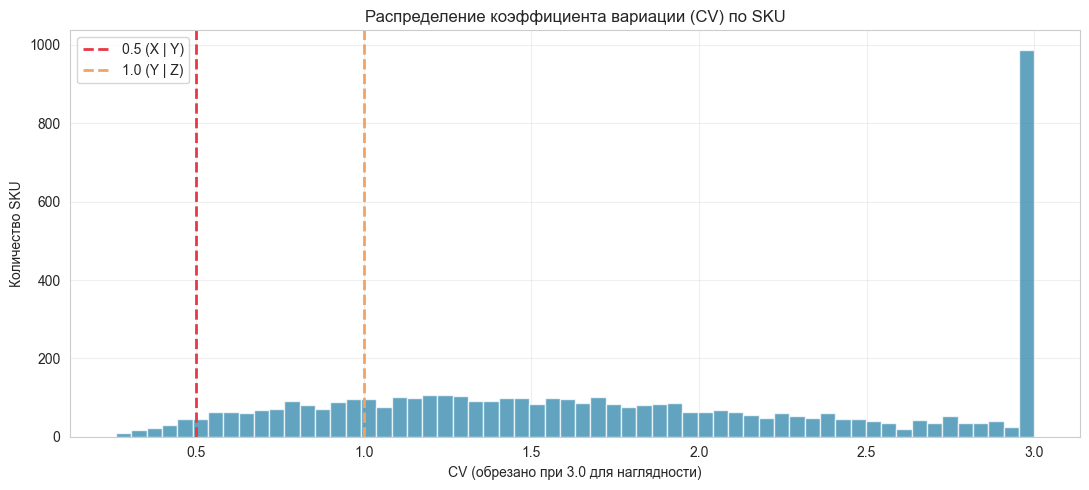

SKU с CV > 3:  964 (19.7%)
SKU с CV > 10: 0 (0.0%)


In [10]:
fig, ax = plt.subplots(figsize=(11, 5))

cv_clipped = xyz["CV"].clip(upper=3)
ax.hist(cv_clipped, bins=60, color="#2E86AB", alpha=0.75, edgecolor="white")

ax.axvline(0.5, color="#E63946", linestyle="--", linewidth=2, label="0.5 (X | Y)")
ax.axvline(1.0, color="#F4A261", linestyle="--", linewidth=2, label="1.0 (Y | Z)")

ax.set_xlabel("CV (обрезано при 3.0 для наглядности)")
ax.set_ylabel("Количество SKU")
ax.set_title("Распределение коэффициента вариации (CV) по SKU")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "xyz_cv_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"SKU с CV > 3:  {(xyz['CV'] > 3).sum():,} "
      f"({(xyz['CV'] > 3).sum() / len(xyz) * 100:.1f}%)")
print(f"SKU с CV > 10: {(xyz['CV'] > 10).sum():,} "
      f"({(xyz['CV'] > 10).sum() / len(xyz) * 100:.1f}%)")

In [7]:
xyz_reset = xyz.reset_index()

abc_desc = read_sql("SELECT stock_code, description, abc_category, revenue FROM abc;")
xyz_reset = xyz_reset.merge(abc_desc, on="stock_code", how="left")

x_top = (
    xyz_reset[xyz_reset["xyz_category"] == "X"]
    .sort_values("total_qty", ascending=False)
    .head(20)
)

print("ТОП-20 стабильных X (по total_qty за 24 месяца):")
display(x_top[[
    "stock_code", "description", "abc_category",
    "mean_qty", "std_qty", "CV", "total_qty",
]])

ТОП-20 стабильных X (по total_qty за 24 месяца):


,stock_code,description,abc_category,mean_qty,std_qty,CV,total_qty
4269,85099B,RED RETROSPOT JUMBO BAG,A,"4,051.8333","1,265.9811",0.3124,"97,244.0000"
615,21212,PACK OF 72 RETROSPOT CAKE CASES,A,"4,004.2083","1,222.5662",0.3053,"96,101.0000"
4297,85123A,WHITE HANGING HEART T-LIGHT HOLDER,A,"3,972.1667","1,448.0823",0.3646,"95,332.0000"
1246,21977,PACK OF 60 PINK PAISLEY CAKE CASES,A,"2,356.6250",769.7525,0.3266,"56,559.0000"
4123,84991,60 TEATIME FAIRY CAKE CASES,A,"2,274.1250",907.4513,0.3990,"54,579.0000"
616,21213,PACK OF 72 SKULL CAKE CASES,A,"1,691.2917",742.3788,0.4389,"40,591.0000"
258,20725,LUNCH BAG RED SPOTTY,A,"1,689.3750",441.8019,0.2615,"40,545.0000"
1606,22386,JUMBO BAG PINK WITH WHITE SPOTS,A,"1,640.8750",771.4090,0.4701,"39,381.0000"
632,21232,STRAWBERRY CERAMIC TRINKET POT,A,"1,600.4583",788.7295,0.4928,"38,411.0000"
4271,85099F,JUMBO BAG STRAWBERRY,A,"1,534.1667",600.6962,0.3915,"36,820.0000"


In [8]:
key_skus = ["22423", "85123A", "85099B", "23843", "47566", "84879", "23166"]

key_check = (
    xyz_reset[xyz_reset["stock_code"].isin(key_skus)]
    [[
        "stock_code", "description", "abc_category", "xyz_category",
        "mean_qty", "std_qty", "CV", "total_qty",
    ]]
    .sort_values("stock_code")
)

print("Проверка ключевых SKU из ABC-топа:")
display(key_check)

Проверка ключевых SKU из ABC-топа:


,stock_code,description,abc_category,xyz_category,mean_qty,std_qty,CV,total_qty
1637,22423,REGENCY CAKESTAND 3 TIER,A,Y,"1,130.2917",703.5584,0.6225,"27,127.0000"
2352,23166,MEDIUM CERAMIC TOP STORAGE JAR,A,Z,"3,242.7500","14,800.9408",4.5643,"77,826.0000"
3144,47566,PARTY BUNTING,A,Y,"1,176.7500",848.7680,0.7213,"28,242.0000"
3987,84879,ASSORTED COLOUR BIRD ORNAMENT,A,Y,"3,353.2917","1,843.3114",0.5497,"80,479.0000"
4269,85099B,RED RETROSPOT JUMBO BAG,A,X,"4,051.8333","1,265.9811",0.3124,"97,244.0000"
4297,85123A,WHITE HANGING HEART T-LIGHT HOLDER,A,X,"3,972.1667","1,448.0823",0.3646,"95,332.0000"


In [9]:
xyz_for_db = xyz_reset[[
    "stock_code", "mean_qty", "std_qty", "CV",
    "total_qty", "xyz_category",
]].copy()

execute_sql("""
    DROP TABLE IF EXISTS xyz;
    CREATE TABLE xyz (
        stock_code    text PRIMARY KEY,
        mean_qty      numeric,
        std_qty       numeric,
        cv            numeric,
        total_qty     bigint,
        xyz_category  text
    );
""")

insert_sql = """
    INSERT INTO xyz (stock_code, mean_qty, std_qty, cv, total_qty, xyz_category)
    VALUES (%s, %s, %s, %s, %s, %s);
"""
rows = [tuple(r) for r in xyz_for_db.itertuples(index=False, name=None)]

with psycopg2.connect(**_get_conn_params()) as conn:
    with conn.cursor() as cur:
        cur.executemany(insert_sql, rows)
    conn.commit()

print(f"✅ Таблица xyz сохранена ({len(rows):,} строк)")

# Проверка
display(read_sql("""
    SELECT xyz_category, COUNT(*) AS n
    FROM xyz
    GROUP BY xyz_category
    ORDER BY xyz_category;
"""))

✅ Таблица xyz сохранена (4,894 строк)


,xyz_category,n
0,X,127
1,Y,813
2,Z,3954


## Этап 4. XYZ-анализ стабильности спроса — ВЫВОДЫ (финал)

### Методология
- Полный календарь: **24 месяца** (2009-12 — 2011-11).
- Декабрь 2011 исключён (неполный).
- Для каждого SKU построен временной ряд quantity по месяцам.
- **Отсутствующие месяцы заполнены нулями** — критично для корректного CV.
- **CV = std / mean**, пороги: X ≤ 0.5, Y ≤ 1.0, Z > 1.0.

### Итоговое распределение

| Группа | SKU | Доля SKU | Медианный CV | Total qty | Доля quantity |
|--------|-----|----------|--------------|-----------|---------------|
| **X** (стабильный) | 127 | 2.60% | 0.41 | 1 935 770 | **17.46%** |
| **Y** (умеренный) | 813 | 16.61% | 0.79 | 4 060 024 | 36.61% |
| **Z** (хаотичный) | 3 954 | **80.79%** | 1.99 | 5 093 550 | 45.93% |
| **Всего** | 4 894 | 100% | — | 11 089 344 | 100% |

### Дополнительные метрики
- **Доля нулевых ячеек в матрице SKU × месяц: 45.2%.**
  В среднем каждый товар продаётся только **13 из 24 месяцев**.
- **SKU с CV > 3: 964 (19.7%)** — сильно нестабильные.
- **Медиана CV = 1.72** — половина ассортимента имеет CV > 1.72.

### Ключевые выводы

1. **X-группа — «рабочие лошадки» бизнеса.**
   Всего **127 SKU (2.60% ассортимента)** дают **17.46% всей проданной
   физической продукции**. Это стабильные товары, которые продаются
   каждый месяц с малым разбросом. Их нужно **всегда держать в наличии**.

   Топ X-группы:
   - **85099B RED RETROSPOT JUMBO BAG** — mean 4 052/мес, CV 0.31
   - **21212 PACK OF 72 RETROSPOT CAKE CASES** — mean 4 004/мес, CV 0.31
   - **85123A WHITE HANGING HEART T-LIGHT HOLDER** — mean 3 972/мес, CV 0.36

2. **Z-группа — 80.79% ассортимента**, но только **45.93% quantity**.
   Типичная картина для ритейла. НО это не значит, что товары можно
   удалить. Внутри Z есть:
   - **сезонные товары** (пик в конкретные месяцы);
   - **новые товары** (появились в конце периода);
   - **редкие товары** (1–3 продажи за 2 года);
   - **разовые оптовые сделки** (SKU 23843 PAPER CRAFT).

3. **Порог X ≤ 0.5 оказался строгим.** Классический порог отсеивает
   97% ассортимента. Это наблюдение: для сезонного ритейла можно
   расширить X до CV ≤ 0.7 (даст ~400 SKU вместо 127).
   **Решение:** оставляем классический порог для чистоты метода,
   упоминаем альтернативу в ограничениях.

4. **Проверка топ-10 ABC:**
   - **85099B и 85123A** (топ ABC) → **AX** (идеальное совпадение).
   - **22423 REGENCY CAKESTAND** → **AY** (сезонный, CV 0.62).
   - **47566 PARTY BUNTING** → **AY** (сезонный, CV 0.72).
   - **84879 ASSORTED COLOUR BIRD ORNAMENT** → **AY** (CV 0.55).
   - **23166 MEDIUM CERAMIC TOP STORAGE JAR** → **AZ** (CV 4.56).
   - **23843 PAPER CRAFT** → **A-no_data** (продался только в дек-2011).

5. **Сезонность — основная причина высокого CV.** Многие товары в Z
   не «плохие», а **сезонные**. PARTY BUNTING и REGENCY CAKESTAND
   имеют CV 0.62–0.72 — чуть выше порога X, причина — сезонность.

6. **Ограничения XYZ:**
   - CV не различает сезонность и хаос.
   - Порог X ≤ 0.5 может быть строгим для сезонного ритейла.
   - Товары, появившиеся в конце периода, автоматически попадают в Z.
   - **Продажи ≠ спрос.** Out-of-stock снижает продажи без снижения спроса.

### Что зафиксировано в базе
Таблица `xyz` (4 894 строки) сохранена в Postgres.

### Графики
- `reports/xyz_cv_distribution.png` — распределение CV.

### Что дальше
**Этап 5 (Матрица ABC/XYZ):** соединяем `abc` и `xyz` по `stock_code`.
Получаем 9+1 групп. Для каждой — метрики: SKU, выручка, quantity, заказы, клиенты.